# Student Mental Health Prediction — Artificial Neural Network (ANN)
**Member 3: Shifa Aftab**

This notebook implements and evaluates an Artificial Neural Network (ANN) model to classify student mental distress. It uses the cleaned dataset and 80:20 train-test split prepared in Phase 3 (Data Preprocessing) and Phase 4 (Dataset Preparation): `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`, built from demographics, GAD-7 (anxiety), ISI (insomnia), and PSS (perceived stress) responses. The target variable is `Distressed`.

No additional preprocessing, feature engineering, or re-splitting is performed here — the provided files are used exactly as shared, so results stay comparable with the rest of the team's models.

## Step 1: Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
from google.colab import files
uploaded = files.upload()

Saving X_train.csv to X_train.csv
Saving X_test.csv to X_test.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv


## Step 2: Load the Train/Test Datasets
Files used exactly as shared by the team: `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`.

In [5]:
X_train = pd.read_csv("X_train.csv").astype(float)  # one-hot columns load as bool; cast to float for the network
X_test = pd.read_csv("X_test.csv").astype(float)
y_train = pd.read_csv("y_train.csv")["Distressed"]
y_test = pd.read_csv("y_test.csv")["Distressed"]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)
print("\nFeature columns:")
print(X_train.columns.tolist())

X_train shape: (19433, 39)
X_test shape : (4859, 39)
y_train shape: (19433,)
y_test shape : (4859,)

Feature columns:
['age', 'gad7_q1', 'gad7_q2', 'gad7_q3', 'gad7_q4', 'gad7_q5', 'gad7_q6', 'gad7_q7', 'isi_q1', 'isi_q2', 'isi_q3', 'isi_q4', 'isi_q5', 'isi_q6', 'isi_q7', 'pss_q1', 'pss_q2', 'pss_q3', 'pss_q4', 'pss_q5', 'pss_q6', 'pss_q7', 'pss_q8', 'pss_q9', 'pss_q10', 'pss_q11', 'pss_q12', 'pss_q13', 'pss_q14', 'gender_male', "edu_bachelor's degree", 'edu_doctorate degree', "edu_master's degree", 'smoke_former smoker (cumulative smoking >10 packs), but not in the past year', 'smoke_never smokes', 'smoke_occasional smoker (cumulative smoking <10 packs)', 'drink_drank in the past (more than once a week), but not in the past year', 'drink_drinks occasionally (less than once a week)', 'drink_never drinks']


## Step 3: Feature Scaling
The features mix very different scales — `age` (roughly 15-70), individual 0-3/0-4 questionnaire items, and one-hot encoded 0/1 columns. Neural networks are sensitive to input scale, since large-magnitude features can dominate the learning process, so `StandardScaler` is applied here.

The scaler is fit only on the training data and then applied to the test data, to avoid leaking test-set statistics into training.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 4: Build the ANN (Multi-Layer Perceptron)
A feed-forward neural network with two hidden layers (32 neurons, then 16 neurons), ReLU activation, and the Adam optimizer. `early_stopping=True` halts training automatically if validation performance stops improving, to reduce the risk of overfitting.

In [7]:
model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
    early_stopping=True
)

## Step 5: Train the Model

In [8]:
model.fit(X_train_scaled, y_train)
print(f"Training complete. Stopped after {model.n_iter_} iterations (early stopping).")

Training complete. Stopped after 22 iterations (early stopping).


## Step 6: Make Predictions on Test Data

In [9]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

## Step 7: Calculate Evaluation Metrics

In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

print("===== MODEL EVALUATION METRICS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(cm)

===== MODEL EVALUATION METRICS =====
Accuracy  : 0.9586
Precision : 0.7279
Recall    : 0.3764
F1 Score  : 0.4962
ROC-AUC   : 0.9518

Confusion Matrix:
[[4559   37]
 [ 164   99]]


## Step 8: Display the Confusion Matrix

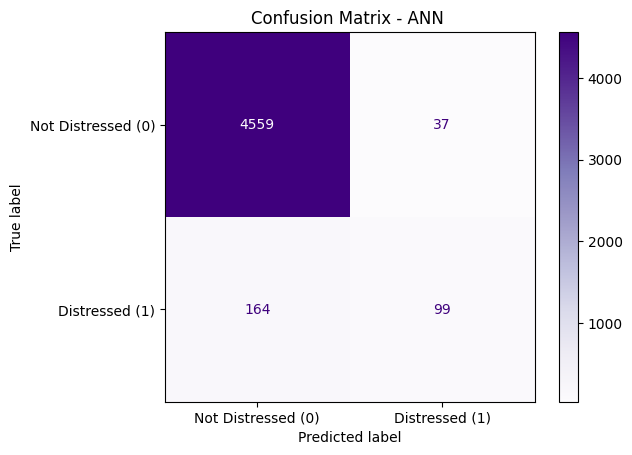

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Distressed (0)", "Distressed (1)"])
disp.plot(cmap="Purples", values_format="d")
plt.title("Confusion Matrix - ANN ")
plt.show()

## Step 9: Plot the ROC Curve

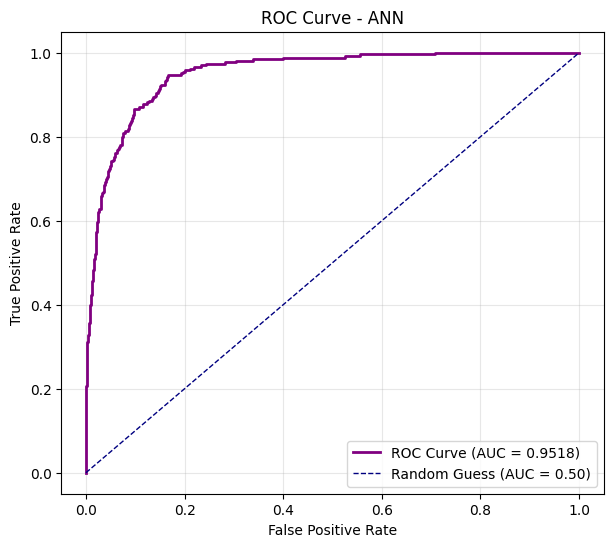

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="purple", linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", linewidth=1, linestyle="--", label="Random Guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ANN")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Step 10: Plot the Training Loss Curve

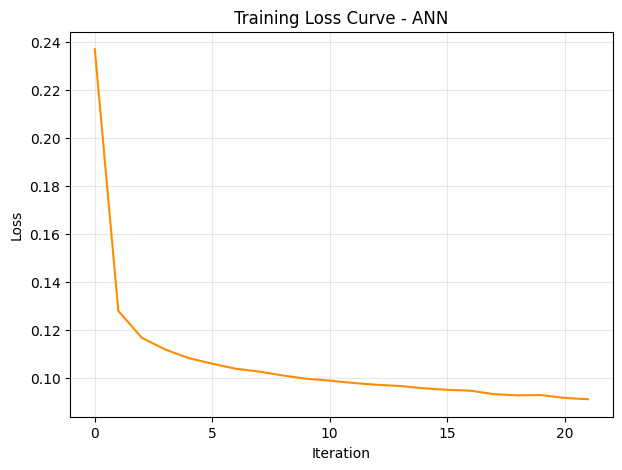

In [13]:
plt.figure(figsize=(7, 5))
plt.plot(model.loss_curve_, color="darkorange")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve - ANN")
plt.grid(alpha=0.3)
plt.show()